In [1]:
import pandas as pd

file_path = 'df_prop.csv'
df = pd.read_csv(file_path)

df.head()

,ID_FAM_ANON,VL_RENDA_MEDIA_FAM,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,IN_FORMULARIO_SUP2_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,...,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,PCT_7A18_ESCOLA_PUBLICA,PCT_MENOR6_FORA_CRECHE_PRE,classe_renda
0,261656,2102.0,2,13,2603,0,5,2,1,1,...,0.0,0.0,0.0,0,0,0.0,0.0,0.000000,0.000000,2
1,5698849,180.0,2,33,100,0,1,1,1,1,...,0.0,0.0,0.0,0,0,0.0,0.0,0.000000,0.000000,0
2,2281296,15.0,2,26,15201,0,3,1,1,1,...,0.0,0.0,0.0,0,0,0.0,0.0,0.333333,0.333333,0
3,4382442,355.0,2,31,57807,0,2,1,1,1,...,0.0,0.0,0.0,0,0,0.0,0.0,0.000000,0.000000,1
4,8585900,1994.0,2,43,4689,0,2,1,1,1,...,0.0,0.0,0.0,0,0,0.0,0.0,0.000000,0.000000,2


In [2]:
df.columns

Index(['ID_FAM_ANON', 'VL_RENDA_MEDIA_FAM', 'IN_TRABALHO_INFANTIL_FAM',
       'CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM',
       'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM',
       'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_

In [3]:
df = df.drop(columns=['VL_RENDA_MEDIA_FAM'])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 51 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   ID_FAM_ANON                   1000000 non-null  int64  
 1   IN_TRABALHO_INFANTIL_FAM      1000000 non-null  int64  
 2   CO_MUNIC_IBGE_2_FAM           1000000 non-null  int64  
 3   CO_MUNIC_IBGE_5_FAM           1000000 non-null  int64  
 4   IN_FORMULARIO_SUP2_FAM        1000000 non-null  int64  
 5   QT_PESSOAS_DOMIC_FAM          1000000 non-null  int64  
 6   QT_FAMILIAS_DOMIC_FAM         1000000 non-null  int64  
 7   CO_ESPECIE_DOMIC_FAM          1000000 non-null  int64  
 8   CO_LOCAL_DOMIC_FAM            1000000 non-null  int64  
 9   QT_COMODOS_DOMIC_FAM          1000000 non-null  int64  
 10  QT_COMODOS_DORMITORIO_FAM     1000000 non-null  int64  
 11  CO_MATERIAL_DOMIC_FAM         1000000 non-null  int64  
 12  CO_MATERIAL_PISO_FAM         

In [5]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression


In [6]:
df['classe_renda'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000000 entries, 0 to 999999
Series name: classe_renda
Non-Null Count    Dtype
--------------    -----
1000000 non-null  int64
dtypes: int64(1)
memory usage: 7.6 MB


In [7]:
df.columns

Index(['ID_FAM_ANON', 'IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM', 'QT_PESSOAS_DOMIC_FAM',
       'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
       'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
       'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
       'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
       'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
       'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
       'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB',
       'CO_SEXO_PESSOA', 'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA',
       'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB',
       'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB',
       'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_TRABALHOU_SEMANA_MEMB',
       'CO_AFASTADO_TRAB_MEMB', 'CO_AGRICULTURA_TRAB_MEMB',
       'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB', 'QTD_PESSOAS'

## Análise de correlação das variáveis

In [8]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# ---- 1) Listas das categorias ----

cat_num_cols = [
    'IN_TRABALHO_INFANTIL_FAM', 'IN_FORMULARIO_SUP2_FAM',
    'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
    'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
    'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
    'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
    'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
    'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM',
    'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
    'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
    'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
    'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
    'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
    'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
    'CO_TRABALHO_12_MESES_MEMB',
]

bool_cols = [
    'TEM_CRIANCA_SEM_ESCOLA',
    'TEM_ADOLESCENTE_SEM_ESCOLA',
    ]

pct_cols = [
    'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
    'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
    'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64',
    'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENCIA', 'PCT_PES_ANALFABETA',
       'PCT_ADULTO_NUNCA_FREQ_ESCOLA', 'PCT_7A18_ESCOLA_PUBLICA',
       'PCT_MENOR6_FORA_CRECHE_PRE', 
]


quant_cols = [
    'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
    'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
    'IDADE_REFERENCIA',
]

# Conjuntos auxiliares para testar tipo rapidamente
cat_all = cat_num_cols + bool_cols    # tratadas como categóricas
num_all = quant_cols + pct_cols                    # tratadas como numéricas

set_cat = set(cat_all)
set_num = set(num_all)

# Todas as variáveis consideradas
all_vars = cat_all + num_all

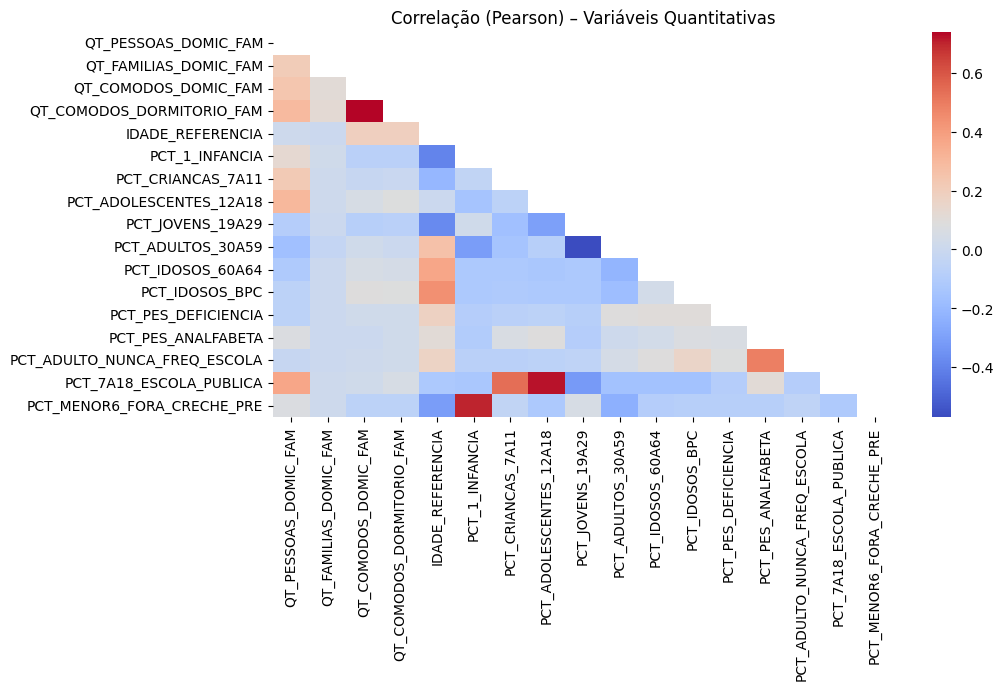

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar apenas quantitativas
df_quant = df[quant_cols + pct_cols]

# Matriz de correlação Pearson
corr_quant = df_quant.corr(method='pearson')

# Máscara acima da diagonal
mask = np.triu(np.ones_like(corr_quant, dtype=bool))

plt.figure(figsize=(10, 5))
sns.heatmap(
    corr_quant.round(2),
    annot=False,
    cmap='coolwarm',
    mask=mask
)
plt.title("Correlação (Pearson) – Variáveis Quantitativas")
plt.show()


In [10]:
# Converter matriz para formato longo (var1, var2, corr)
corr_pairs = (
    corr_quant
        .where(np.triu(np.ones(corr_quant.shape), k=1).astype(bool))  # apenas acima da diagonal
        .stack()
        .reset_index()
)
corr_pairs.columns = ['var1', 'var2', 'corr']

# Ordenar pelas correlações mais fortes (em valor absoluto)
corr_pairs_sorted = corr_pairs.reindex(corr_pairs['corr'].abs().sort_values(ascending=False).index)

# Mostrar top 20
corr_pairs_sorted.head(20)


,var1,var2,corr
31,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,0.744134
98,PCT_ADOLESCENTES_12A18,PCT_7A18_ESCOLA_PUBLICA,0.720162
80,PCT_1_INFANCIA,PCT_MENOR6_FORA_CRECHE_PRE,0.704885
100,PCT_JOVENS_19A29,PCT_ADULTOS_30A59,-0.567895
89,PCT_CRIANCAS_7A11,PCT_7A18_ESCOLA_PUBLICA,0.541241
130,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,0.487395
64,IDADE_REFERENCIA,PCT_IDOSOS_BPC,0.443942
58,IDADE_REFERENCIA,PCT_1_INFANCIA,-0.404894
61,IDADE_REFERENCIA,PCT_JOVENS_19A29,-0.379859
14,QT_PESSOAS_DOMIC_FAM,PCT_7A18_ESCOLA_PUBLICA,0.372782


In [11]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    t = pd.crosstab(x, y)
    if t.shape[0] <= 1 or t.shape[1] <= 1:
        return np.nan
    chi2, p, dof, expected = chi2_contingency(t)
    n = t.to_numpy().sum()
    r, k = t.shape
    return np.sqrt(chi2 / (n*(min(r,k)-1)))


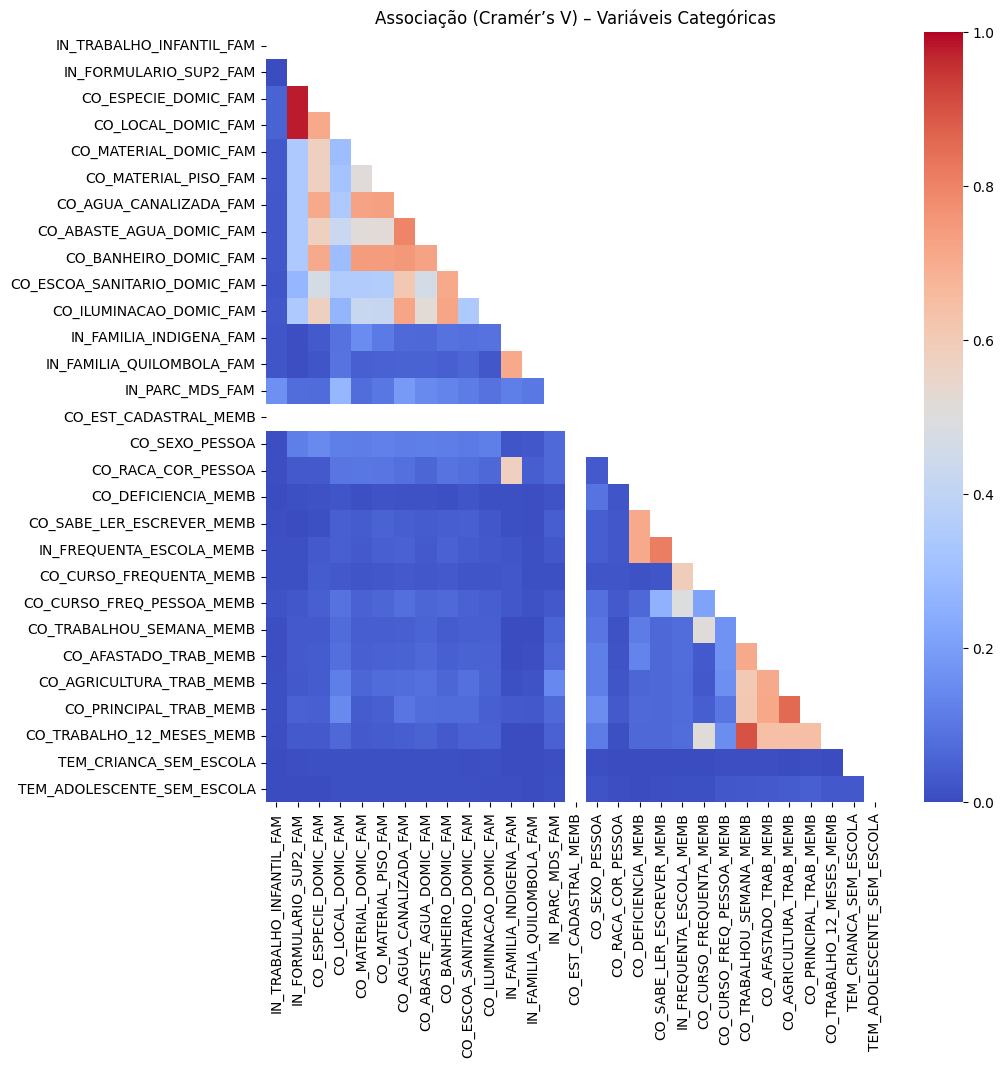

In [12]:
# Selecionar todas as categóricas
df_cat = df[cat_num_cols + bool_cols]

# Matriz vazia
cramers_mat = pd.DataFrame(index=df_cat.columns, columns=df_cat.columns)

# Preencher matriz
for c1 in df_cat.columns:
    for c2 in df_cat.columns:
        if c1 == c2:
            cramers_mat.loc[c1, c2] = 1
        else:
            cramers_mat.loc[c1, c2] = cramers_v(df_cat[c1], df_cat[c2])

# Converter para float
cramers_mat = cramers_mat.astype(float)

# Máscara
mask = np.triu(np.ones_like(cramers_mat, dtype=bool))

plt.figure(figsize=(10, 10))
sns.heatmap(
    cramers_mat,
    annot=False,
    cmap='coolwarm',
    mask=mask,
    vmax=1,
    vmin=0
)
plt.title("Associação (Cramér’s V) – Variáveis Categóricas")
plt.show()


In [13]:
import numpy as np
import pandas as pd

# partindo de cramers_mat já calculada

# 1) Pegar só a parte acima da diagonal para evitar duplicação
cramers_pairs = (
    cramers_mat
        .where(np.triu(np.ones(cramers_mat.shape), k=1).astype(bool))  # mantém só acima da diagonal
        .stack()                                                       # transforma em série longa
        .reset_index()
)

cramers_pairs.columns = ['var1', 'var2', 'cramers_v']

# 2) Ordenar pelas maiores associações
cramers_pairs_sorted = cramers_pairs.sort_values('cramers_v', ascending=False)

# 3) Ver as 30 maiores associações
print("Top 30 pares com maior Cramér's V:")
print(cramers_pairs_sorted.head(10))


Top 30 pares com maior Cramér's V:
                          var1                       var2  cramers_v
27      IN_FORMULARIO_SUP2_FAM       CO_ESPECIE_DOMIC_FAM   0.979773
28      IN_FORMULARIO_SUP2_FAM         CO_LOCAL_DOMIC_FAM   0.979773
360   CO_TRABALHOU_SEMANA_MEMB  CO_TRABALHO_12_MESES_MEMB   0.900349
368   CO_AGRICULTURA_TRAB_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.858930
323  CO_SABE_LER_ESCREVER_MEMB   IN_FREQUENTA_ESCOLA_MEMB   0.816102
147     CO_AGUA_CANALIZADA_FAM   CO_ABASTE_AGUA_DOMIC_FAM   0.799237
148     CO_AGUA_CANALIZADA_FAM      CO_BANHEIRO_DOMIC_FAM   0.750585
105      CO_MATERIAL_DOMIC_FAM      CO_BANHEIRO_DOMIC_FAM   0.745603
127       CO_MATERIAL_PISO_FAM      CO_BANHEIRO_DOMIC_FAM   0.742447
125       CO_MATERIAL_PISO_FAM     CO_AGUA_CANALIZADA_FAM   0.733691


In [14]:
# Definir um limiar para "associação muito alta"
threshold = 0.80

cramers_high = cramers_pairs_sorted[cramers_pairs_sorted['cramers_v'] >= threshold]

print(f"\nPares com Cramér's V >= {threshold}:")
print(cramers_high)



Pares com Cramér's V >= 0.8:
                          var1                       var2  cramers_v
27      IN_FORMULARIO_SUP2_FAM       CO_ESPECIE_DOMIC_FAM   0.979773
28      IN_FORMULARIO_SUP2_FAM         CO_LOCAL_DOMIC_FAM   0.979773
360   CO_TRABALHOU_SEMANA_MEMB  CO_TRABALHO_12_MESES_MEMB   0.900349
368   CO_AGRICULTURA_TRAB_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.858930
323  CO_SABE_LER_ESCREVER_MEMB   IN_FREQUENTA_ESCOLA_MEMB   0.816102


In [15]:
df = df.drop(columns=['IN_FORMULARIO_SUP2_FAM', 'CO_TRABALHOU_SEMANA_MEMB', 'CO_AGRICULTURA_TRAB_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB'])

In [16]:
df.columns

Index(['ID_FAM_ANON', 'IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
       'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'CO_CURSO_FREQUENTA_MEMB',
       'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB', 'QTD_PESSOAS',
       'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11', 'PCT_ADOLESCENTES_12A18',
       'PCT_JOVENS_19A29', 'PCT_ADULTOS_30A59', 'P

In [17]:
df.head()

,ID_FAM_ANON,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,...,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,PCT_7A18_ESCOLA_PUBLICA,PCT_MENOR6_FORA_CRECHE_PRE,classe_renda
0,261656,2,13,2603,5,2,1,1,5,3,...,0.0,0.0,0.0,0,0,0.0,0.0,0.000000,0.000000,2
1,5698849,2,33,100,1,1,1,1,2,1,...,0.0,0.0,0.0,0,0,0.0,0.0,0.000000,0.000000,0
2,2281296,2,26,15201,3,1,1,1,5,2,...,0.0,0.0,0.0,0,0,0.0,0.0,0.333333,0.333333,0
3,4382442,2,31,57807,2,1,1,1,7,2,...,0.0,0.0,0.0,0,0,0.0,0.0,0.000000,0.000000,1
4,8585900,2,43,4689,2,1,1,1,5,2,...,0.0,0.0,0.0,0,0,0.0,0.0,0.000000,0.000000,2


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 47 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   ID_FAM_ANON                   1000000 non-null  int64  
 1   IN_TRABALHO_INFANTIL_FAM      1000000 non-null  int64  
 2   CO_MUNIC_IBGE_2_FAM           1000000 non-null  int64  
 3   CO_MUNIC_IBGE_5_FAM           1000000 non-null  int64  
 4   QT_PESSOAS_DOMIC_FAM          1000000 non-null  int64  
 5   QT_FAMILIAS_DOMIC_FAM         1000000 non-null  int64  
 6   CO_ESPECIE_DOMIC_FAM          1000000 non-null  int64  
 7   CO_LOCAL_DOMIC_FAM            1000000 non-null  int64  
 8   QT_COMODOS_DOMIC_FAM          1000000 non-null  int64  
 9   QT_COMODOS_DORMITORIO_FAM     1000000 non-null  int64  
 10  CO_MATERIAL_DOMIC_FAM         1000000 non-null  int64  
 11  CO_MATERIAL_PISO_FAM          1000000 non-null  int64  
 12  CO_AGUA_CANALIZADA_FAM       

## Pre-processamento
### Detectando as colunas categóricas binárias e multicategóricas

In [19]:
df.columns

Index(['ID_FAM_ANON', 'IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
       'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'CO_CURSO_FREQUENTA_MEMB',
       'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB', 'QTD_PESSOAS',
       'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11', 'PCT_ADOLESCENTES_12A18',
       'PCT_JOVENS_19A29', 'PCT_ADULTOS_30A59', 'P

In [20]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Listas de cada categoria
cat_num_cols = [
    'IN_TRABALHO_INFANTIL_FAM', 
    'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
    'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
    'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
    'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
    'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
    'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM',
    'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
    'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
    'CO_SABE_LER_ESCREVER_MEMB', 'CO_CURSO_FREQUENTA_MEMB', 
    'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
    'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB',
    ]

bool_cols = [
        'TEM_CRIANCA_SEM_ESCOLA',
        'TEM_ADOLESCENTE_SEM_ESCOLA',
        ]

pct_cols = [
         'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
      'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
      'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64',
      'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENCIA', 'PCT_PES_ANALFABETA',
       'PCT_ADULTO_NUNCA_FREQ_ESCOLA', 'PCT_7A18_ESCOLA_PUBLICA',
       'PCT_MENOR6_FORA_CRECHE_PRE',
    ]

quant_cols = [
        'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
        'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
        'IDADE_REFERENCIA',
    ]

geo_cols = ['CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM']

target_col = "classe_renda"
id_col = "ID_FAM_ANON"


In [21]:
# X e y brutos
X = df.drop(columns=[target_col, id_col])
y = df[target_col]

# Garante que as listas só pegam colunas que realmente existem
cat_num_cols_eff = [c for c in cat_num_cols if c in X.columns]
bool_cols_eff    = [c for c in bool_cols    if c in X.columns]
pct_cols_eff     = [c for c in pct_cols     if c in X.columns]
quant_cols_eff   = [c for c in quant_cols   if c in X.columns]
geo_cols_eff     = [c for c in geo_cols     if c in X.columns]

# Detectar binárias e multicategóricas dentro de cat_num_cols
binary_cols = []
multicat_cols = []

for col in cat_num_cols_eff:
    n_unique = X[col].nunique()
    if n_unique == 2:
        binary_cols.append(col)
    elif n_unique > 2:
        multicat_cols.append(col)

print("Binárias:", binary_cols)
print("Multicategóricas:", multicat_cols)

Binárias: ['CO_SEXO_PESSOA']
Multicategóricas: ['IN_TRABALHO_INFANTIL_FAM', 'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB', 'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_AFASTADO_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB']


In [22]:
# Pipeline quantitativas contínuas
pipeline_quant = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", MinMaxScaler()),
])

In [23]:
#Pipeline categorias multiclasses (One-hot)
pipeline_multicat = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

In [24]:
# Pipeline para binárias
pipeline_binary = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ])


In [25]:
# Pipeline percentuais (já estão entre 0 e 1)
pipeline_pct = "passthrough"

In [26]:
# Pipeline booleanas
pipeline_bool = "passthrough"

In [27]:
#Pipeline geográficas (não usar one-hot pois vai criar muitas colunas)
pipeline_geo = "passthrough"

In [28]:
#Construindo ColumnsTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("quant", pipeline_quant, quant_cols),
        ("pct", pipeline_pct, pct_cols),
        ("bool", pipeline_bool, bool_cols),
        ("binary", pipeline_binary, binary_cols),
        ("multicat", pipeline_multicat, multicat_cols),
        ("geo", pipeline_geo, geo_cols),
    ],
    remainder="drop"  # remove colunas que não foram especificadas
)

## Separando em treino e teste

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Visualizando a transformação

In [30]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('quant',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', MinMaxScaler())]),
                                 ['QT_PESSOAS_DOMIC_FAM',
                                  'QT_FAMILIAS_DOMIC_FAM',
                                  'QT_COMODOS_DOMIC_FAM',
                                  'QT_COMODOS_DORMITORIO_FAM',
                                  'IDADE_REFERENCIA']),
                                ('pct', 'passthrough',
                                 ['PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
                                  'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29'...
                                  'CO_ILUMINACAO_DOMIC_FAM',
                                  'IN_FAMILIA_INDIGENA_FAM',
                                  'IN_FAMILIA_QUILOMBOLA_FAM',
                                  'IN_PARC_MDS_FAM', 'CO_RACA_COR_PESSOA',
                                  'CO_DEFICIENCIA_MEMB',
                                  'CO_SABE_LER_ESCREVER_MEMB',
                                  'CO_CURSO_FREQUENTA_MEMB',
                                  'CO_CURSO_FREQ_PESSOA_MEMB',
                                  'CO_AFASTADO_TRAB_MEMB',
                                  'CO_PRINCIPAL_TRAB_MEMB',
                                  'CO_TRABALHO_12_MESES_MEMB']),
                                ('geo', 'passthrough',
                                 ['CO_MUNIC_IBGE_2_FAM',
                                  'CO_MUNIC_IBGE_5_FAM'])])

In [31]:
X_train_trans = preprocessor.transform(X_train)

feature_names = preprocessor.get_feature_names_out()

import pandas as pd
df_train_trans = pd.DataFrame(X_train_trans, columns=feature_names)

df_train_trans.head()

,quant__QT_PESSOAS_DOMIC_FAM,quant__QT_FAMILIAS_DOMIC_FAM,quant__QT_COMODOS_DOMIC_FAM,quant__QT_COMODOS_DORMITORIO_FAM,quant__IDADE_REFERENCIA,pct__PCT_1_INFANCIA,pct__PCT_CRIANCAS_7A11,pct__PCT_ADOLESCENTES_12A18,pct__PCT_JOVENS_19A29,pct__PCT_ADULTOS_30A59,...,multicat__CO_PRINCIPAL_TRAB_MEMB_7,multicat__CO_PRINCIPAL_TRAB_MEMB_8,multicat__CO_PRINCIPAL_TRAB_MEMB_9,multicat__CO_PRINCIPAL_TRAB_MEMB_10,multicat__CO_PRINCIPAL_TRAB_MEMB_11,multicat__CO_TRABALHO_12_MESES_MEMB_-1,multicat__CO_TRABALHO_12_MESES_MEMB_1,multicat__CO_TRABALHO_12_MESES_MEMB_2,geo__CO_MUNIC_IBGE_2_FAM,geo__CO_MUNIC_IBGE_5_FAM
0,0.031915,0.02,0.063830,0.049180,0.293578,0.00,0.00,0.0,0.50,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,42.0,16305.0
1,0.031915,0.02,0.074468,0.065574,0.027523,0.00,0.00,0.0,0.50,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,29.0,30105.0
2,0.053191,0.02,0.074468,0.065574,0.412844,0.00,0.00,0.0,0.75,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,31.0,37908.0
3,0.053191,0.02,0.063830,0.049180,0.165138,0.25,0.25,0.0,0.00,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,29.0,31350.0
4,0.031915,0.02,0.042553,0.032787,0.201835,0.00,0.00,0.5,0.00,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,15.0,1907.0


### Comparando diversos modelos

In [32]:
!pip install xgboost --quiet


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
!pip install catboost --quiet


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# ------------------------------------------------------------
# 1) MODELOS
# ------------------------------------------------------------
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1
    ),
    "LogisticRegression": LogisticRegression(
        max_iter=1000, multi_class="auto", n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.1,
        depth=6,
        loss_function="MultiClass",
        eval_metric="MultiClass",
        random_seed=42,
        verbose=False
    ),
}

# ------------------------------------------------------------
# 2) TREINO + AVALIAÇÃO (sem salvar em disco)
# ------------------------------------------------------------
pipes = {}      # pipelines treinados em memória (no notebook)
results = []    # métricas

for name, clf in models.items():
    print(f"\nTreinando modelo: {name}")

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", clf)
    ])

    pipe.fit(X_train, y_train)

    # guarda pipeline treinado em memória
    pipes[name] = pipe

    # predições
    y_pred = pipe.predict(X_test).ravel()

    # métricas principais
    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average="weighted")
    f1_m = f1_score(y_test, y_pred, average="macro")

    # precisão e revocação (macro e weighted)
    prec_m = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec_m  = recall_score(y_test, y_pred, average="macro", zero_division=0)

    prec_w = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec_w  = recall_score(y_test, y_pred, average="weighted", zero_division=0)

    # AUC (se existir predict_proba)
    try:
        y_proba = pipe.predict_proba(X_test)
        auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
    except Exception:
        auc = np.nan

    results.append({
        "modelo": name,
        "accuracy": acc,
        "f1_weighted": f1_w,
        "f1_macro": f1_m,
        "precision_macro": prec_m,
        "recall_macro": rec_m,
        "precision_weighted": prec_w,
        "recall_weighted": rec_w,
        "auc_weighted_ovr": auc,
    })

# ------------------------------------------------------------
# 3) RESULTADOS (tabela final)
# ------------------------------------------------------------
df_results = pd.DataFrame(results).sort_values("accuracy", ascending=False)
df_results







Treinando modelo: RandomForest

Treinando modelo: LogisticRegression


C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Treinando modelo: GradientBoosting

Treinando modelo: HistGradientBoosting

Treinando modelo: XGBoost

Treinando modelo: CatBoost


,modelo,accuracy,f1_weighted,f1_macro,precision_macro,recall_macro,precision_weighted,recall_weighted,auc_weighted_ovr
4,XGBoost,0.683015,0.659163,0.562998,0.631356,0.541017,0.663458,0.683015,0.802499
3,HistGradientBoosting,0.682725,0.659269,0.563561,0.629998,0.541733,0.663032,0.682725,0.801298
5,CatBoost,0.680725,0.655622,0.556670,0.631301,0.534898,0.661598,0.680725,0.799573
2,GradientBoosting,0.672055,0.640670,0.530740,0.627542,0.511874,0.653043,0.672055,0.788488
0,RandomForest,0.663170,0.641283,0.541536,0.593472,0.523926,0.640395,0.663170,0.775524
1,LogisticRegression,0.640910,0.593519,0.451129,0.583027,0.452653,0.615331,0.640910,0.744949


In [35]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# Modelos que você quer comparar (já treinados e guardados em memória no dict `pipes`)
modelos_alvo = ["XGBoost", "HistGradientBoosting", "CatBoost"]

# 1) Relatório por classe (precision/recall/f1/support) + métricas agregadas
rows = []
reports = {}

for nome in modelos_alvo:
    pipe = pipes[nome]
    y_pred = pipe.predict(X_test).ravel()

    rep = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    reports[nome] = rep  # guarda se quiser inspecionar depois

    # adiciona linhas por classe (0,1,2) e também macro/weighted
    for k, v in rep.items():
        if k in ["0", "1", "2", "macro avg", "weighted avg"]:
            rows.append({
                "modelo": nome,
                "classe": k,
                "precision": v["precision"],
                "recall": v["recall"],
                "f1": v["f1-score"],
                "support": v["support"]
            })

df_por_classe = pd.DataFrame(rows)

# ordenar para facilitar leitura: por modelo e depois classe
ordem_classe = {"0": 0, "1": 1, "2": 2, "macro avg": 3, "weighted avg": 4}
df_por_classe["ordem"] = df_por_classe["classe"].map(ordem_classe)
df_por_classe = df_por_classe.sort_values(["modelo", "ordem"]).drop(columns="ordem")

print("=== Performance por classe (XGBoost, HistGradientBoosting, CatBoost) ===")
display(df_por_classe)

# 2) Resumo “enxuto” focado na Classe 2 (o que você quer minimizar é FN -> maximizar recall_cl2)
df_cl2 = (
    df_por_classe[df_por_classe["classe"] == "2"]
    .copy()
    .sort_values(["recall", "precision"], ascending=False)
    .reset_index(drop=True)
)

print("\n=== Foco na Classe 2 (quanto maior o recall, menor a chance de FN) ===")
display(df_cl2)

# 3) (Opcional, mas muito útil) FN e FP da classe 2 via matriz de confusão
#    FN_cl2 = classe 2 real e modelo previu 0 ou 1
#    FP_cl2 = modelo previu 2 mas real era 0 ou 1
fnfp_rows = []

for nome in modelos_alvo:
    pipe = pipes[nome]
    y_pred = pipe.predict(X_test).ravel()

    # assumindo classes 0,1,2
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])

    TP = cm[2, 2]
    FN = cm[2, 0] + cm[2, 1]
    FP = cm[0, 2] + cm[1, 2]
    TN = cm.sum() - (TP + FN + FP)

    fnfp_rows.append({
        "modelo": nome,
        "TP_cl2": int(TP),
        "FN_cl2": int(FN),
        "FP_cl2": int(FP),
        "TN_cl2": int(TN),
        "recall_cl2": TP / (TP + FN) if (TP + FN) > 0 else 0.0,
        "precision_cl2": TP / (TP + FP) if (TP + FP) > 0 else 0.0
    })

df_fnfp_cl2 = pd.DataFrame(fnfp_rows).sort_values(["recall_cl2", "precision_cl2"], ascending=False)

print("\n=== Classe 2: TP/FN/FP/TN (FN menor = melhor para não 'perder' classe 2) ===")
display(df_fnfp_cl2)


=== Performance por classe (XGBoost, HistGradientBoosting, CatBoost) ===


,modelo,classe,precision,recall,f1,support
10,CatBoost,0,0.639063,0.291884,0.400737,27576.0
11,CatBoost,1,0.521633,0.414193,0.461746,55421.0
12,CatBoost,2,0.733206,0.898618,0.807528,117003.0
13,CatBoost,macro avg,0.631301,0.534898,0.556670,200000.0
14,CatBoost,weighted avg,0.661598,0.680725,0.655622,200000.0
5,HistGradientBoosting,0,0.628283,0.313207,0.418024,27576.0
6,HistGradientBoosting,1,0.525202,0.415691,0.464073,55421.0
7,HistGradientBoosting,2,0.736509,0.896302,0.808586,117003.0
8,HistGradientBoosting,macro avg,0.629998,0.541733,0.563561,200000.0
9,HistGradientBoosting,weighted avg,0.663032,0.682725,0.659269,200000.0



=== Foco na Classe 2 (quanto maior o recall, menor a chance de FN) ===


,modelo,classe,precision,recall,f1,support
0,CatBoost,2,0.733206,0.898618,0.807528,117003.0
1,XGBoost,2,0.736136,0.897849,0.808990,117003.0
2,HistGradientBoosting,2,0.736509,0.896302,0.808586,117003.0



=== Classe 2: TP/FN/FP/TN (FN menor = melhor para não 'perder' classe 2) ===


,modelo,TP_cl2,FN_cl2,FP_cl2,TN_cl2,recall_cl2,precision_cl2
2,CatBoost,105141,11862,38258,44739,0.898618,0.733206
0,XGBoost,105051,11952,37655,45342,0.897849,0.736136
1,HistGradientBoosting,104870,12133,37518,45479,0.896302,0.736509


## Ajuste manual de hiperparâmetros

In [36]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

CLASSE_FOCO = 2

def avaliar(pipe, X_test, y_test):
    y_pred = pipe.predict(X_test).ravel()

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted"),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "precision_cl2": precision_score(
            y_test, y_pred, labels=[CLASSE_FOCO], average="macro", zero_division=0
        ),
        "recall_cl2": recall_score(
            y_test, y_pred, labels=[CLASSE_FOCO], average="macro", zero_division=0
        ),
        "f1_cl2": f1_score(
            y_test, y_pred, labels=[CLASSE_FOCO], average="macro", zero_division=0
        )
    }

rows = []

# ============================================================
# 1) CATBOOST – AJUSTES CIRÚRGICOS
# ============================================================
cat_configs = {
    "cat_base": dict(iterations=300, learning_rate=0.1, depth=6,
                     l2_leaf_reg=3, bagging_temperature=1.0),

    "cat_recall_up": dict(iterations=600, learning_rate=0.05, depth=7,
                          l2_leaf_reg=5, bagging_temperature=1.5),

    "cat_recall_up_strong": dict(iterations=800, learning_rate=0.04, depth=7,
                                 l2_leaf_reg=10, bagging_temperature=2.0),
}

for nome, params in cat_configs.items():
    clf = CatBoostClassifier(
        loss_function="MultiClass",
        eval_metric="MultiClass",
        random_seed=42,
        verbose=False,
        **params
    )

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", clf)
    ])

    pipe.fit(X_train, y_train)
    mets = avaliar(pipe, X_test, y_test)

    rows.append({
        "modelo": "CatBoost",
        "config": nome,
        **params,
        **mets
    })

# ============================================================
# 2) XGBOOST – AJUSTES CIRÚRGICOS
# ============================================================
xgb_configs = {
    "xgb_base": dict(n_estimators=300, learning_rate=0.1, max_depth=6,
                     min_child_weight=3, gamma=0.0),

    "xgb_recall_up": dict(n_estimators=600, learning_rate=0.05, max_depth=6,
                          min_child_weight=1, gamma=0.0),

    "xgb_recall_up_reg": dict(n_estimators=800, learning_rate=0.04, max_depth=5,
                              min_child_weight=1, gamma=0.0, reg_lambda=3),
}

for nome, params in xgb_configs.items():
    clf = XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        **params
    )

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", clf)
    ])

    pipe.fit(X_train, y_train)
    mets = avaliar(pipe, X_test, y_test)

    rows.append({
        "modelo": "XGBoost",
        "config": nome,
        **params,
        **mets
    })

# ============================================================
# RESULTADO FINAL
# ============================================================
df_step2 = pd.DataFrame(rows)

df_step2 = df_step2.sort_values(
    ["recall_cl2", "precision_cl2"],
    ascending=False
)

print("=== RESULTADOS – AJUSTE CIRÚRGICO (FOCO CLASSE 2) ===")
display(df_step2[
    ["modelo","config",
     "recall_cl2","precision_cl2","f1_cl2",
     "f1_weighted","accuracy"]
])


=== RESULTADOS – AJUSTE CIRÚRGICO (FOCO CLASSE 2) ===


,modelo,config,recall_cl2,precision_cl2,f1_cl2,f1_weighted,accuracy
2,CatBoost,cat_recall_up_strong,0.898977,0.733151,0.807640,0.655727,0.680860
1,CatBoost,cat_recall_up,0.898857,0.733575,0.807849,0.656031,0.681040
0,CatBoost,cat_base,0.898618,0.733206,0.807528,0.655622,0.680725
5,XGBoost,xgb_recall_up_reg,0.898045,0.734059,0.807814,0.656932,0.681435
4,XGBoost,xgb_recall_up,0.897490,0.735677,0.808567,0.658646,0.682540
3,XGBoost,xgb_base,0.897370,0.735718,0.808543,0.658830,0.682670


In [37]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
CLASSE_FOCO = 2
THRESHOLDS = np.arange(0.30, 0.61, 0.05)  # ajuste fino aqui se quiser

# usar o melhor CatBoost já treinado
pipe = None
for nome, p in pipes.items():
    if nome == "CatBoost":
        pipe = p
        break

assert pipe is not None, "Pipeline CatBoost não encontrado em pipes"

# ------------------------------------------------------------
# PROBABILIDADES
# ------------------------------------------------------------
proba = pipe.predict_proba(X_test)          # shape (n, 3)
pred_base = pipe.predict(X_test).ravel()    # argmax padrão

rows = []

for t in THRESHOLDS:
    y_pred_thr = pred_base.copy()

    # regra de override para classe 2
    mask = proba[:, CLASSE_FOCO] >= t
    y_pred_thr[mask] = CLASSE_FOCO

    # métricas focadas na classe 2
    prec = precision_score(
        y_test, y_pred_thr, labels=[CLASSE_FOCO], average="macro", zero_division=0
    )
    rec = recall_score(
        y_test, y_pred_thr, labels=[CLASSE_FOCO], average="macro", zero_division=0
    )
    f1 = f1_score(
        y_test, y_pred_thr, labels=[CLASSE_FOCO], average="macro", zero_division=0
    )

    # FN e FP explícitos
    cm = confusion_matrix(y_test, y_pred_thr, labels=[0, 1, 2])
    TP = cm[2, 2]
    FN = cm[2, 0] + cm[2, 1]
    FP = cm[0, 2] + cm[1, 2]

    rows.append({
        "threshold_cl2": t,
        "recall_cl2": rec,
        "precision_cl2": prec,
        "f1_cl2": f1,
        "FN_cl2": int(FN),
        "FP_cl2": int(FP),
    })

df_threshold = pd.DataFrame(rows)

# ordenar priorizando recall e controlando precisão
df_threshold = df_threshold.sort_values(
    ["recall_cl2", "precision_cl2"],
    ascending=False
).reset_index(drop=True)

print("=== AJUSTE DE THRESHOLD – CLASSE 2 ===")
display(df_threshold)


=== AJUSTE DE THRESHOLD – CLASSE 2 ===


,threshold_cl2,recall_cl2,precision_cl2,f1_cl2,FN_cl2,FP_cl2
0,0.30,0.952788,0.694128,0.803145,5524,49124
1,0.35,0.933779,0.710893,0.807233,7748,44432
2,0.40,0.913908,0.724635,0.808340,10073,40634
3,0.45,0.899917,0.732555,0.807657,11710,38441
4,0.50,0.898618,0.733206,0.807528,11862,38258
5,0.55,0.898618,0.733206,0.807528,11862,38258
6,0.60,0.898618,0.733206,0.807528,11862,38258


# Pipeline processamento + Modelo (CatBoost)

In [38]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted
import numpy as np
from catboost import CatBoostClassifier

class CatBoostComThreshold(BaseEstimator, ClassifierMixin):
    def __init__(self, threshold_cl2=0.35):
        self.threshold_cl2 = threshold_cl2

        self.model = CatBoostClassifier(
            loss_function="MultiClass",
            eval_metric="MultiClass",
            random_seed=42,
            verbose=False,
            iterations=600,
            learning_rate=0.05,
            depth=7,
            l2_leaf_reg=5,
            bagging_temperature=1.5
        )

    def fit(self, X, y):
        self.model.fit(X, y)
        self.classes_ = np.unique(y)
        return self

    def predict_proba(self, X):
        check_is_fitted(self, attributes=["classes_"])
        return self.model.predict_proba(X)

    def predict(self, X):
        check_is_fitted(self, attributes=["classes_"])
        proba = self.model.predict_proba(X)
        y_pred = np.argmax(proba, axis=1)
        y_pred[proba[:, 2] >= self.threshold_cl2] = 2
        return y_pred



In [39]:
from sklearn.pipeline import Pipeline

pipeline_final = Pipeline([
    ("preprocess", preprocessor),
    ("model", CatBoostComThreshold(threshold_cl2=0.35))
])

pipeline_final.fit(X_train, y_train)





Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('quant',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  ['QT_PESSOAS_DOMIC_FAM',
                                                   'QT_FAMILIAS_DOMIC_FAM',
                                                   'QT_COMODOS_DOMIC_FAM',
                                                   'QT_COMODOS_DORMITORIO_FAM',
                                                   'IDADE_REFERENCIA']),
                                                 ('pct', 'passthrough',
                                                  ['PCT_1_INFANCIA',
                                                   'PCT_CRIANCAS_7A11',
                                                   'PCT_ADOLESCE...
                                                   'IN_FAMILIA_QUILOMBOLA_FAM',
                                                   'IN_PARC_MDS_FAM',
                                                   'CO_RACA_COR_PESSOA',
                                                   'CO_DEFICIENCIA_MEMB',
                                                   'CO_SABE_LER_ESCREVER_MEMB',
                                                   'CO_CURSO_FREQUENTA_MEMB',
                                                   'CO_CURSO_FREQ_PESSOA_MEMB',
                                                   'CO_AFASTADO_TRAB_MEMB',
                                                   'CO_PRINCIPAL_TRAB_MEMB',
                                                   'CO_TRABALHO_12_MESES_MEMB']),
                                                 ('geo', 'passthrough',
                                                  ['CO_MUNIC_IBGE_2_FAM',
                                                   'CO_MUNIC_IBGE_5_FAM'])])),
                ('model', CatBoostComThreshold())])

## Avaliação completa do Modelo

### Predições do teste

In [40]:
y_pred = pipeline_final.predict(X_test)
y_proba = pipeline_final.predict_proba(X_test)  # para AUC

### Acurácia, F1, Precisão e revocação

In [41]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

acc = accuracy_score(y_test, y_pred)

f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)

precision_weighted = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall_weighted = recall_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Acurácia: {acc:.3f}")
print(f"F1 macro: {f1_macro:.3f}")
print(f"F1 weighted: {f1_weighted:.3f}")
print(f"Precisão macro: {precision_macro:.3f}")
print(f"Revocação macro: {recall_macro:.3f}")
print(f"Precisão weighted: {precision_weighted:.3f}")
print(f"Revocação weighted: {recall_weighted:.3f}")


Acurácia: 0.678
F1 macro: 0.539
F1 weighted: 0.641
Precisão macro: 0.630
Revocação macro: 0.519
Precisão weighted: 0.654
Revocação weighted: 0.678


### Classification report

In [42]:
print("Classification report:")
print(classification_report(y_test, y_pred))

Classification report:
              precision    recall  f1-score   support

           0       0.64      0.29      0.40     27576
           1       0.54      0.33      0.41     55421
           2       0.71      0.93      0.81    117003

    accuracy                           0.68    200000
   macro avg       0.63      0.52      0.54    200000
weighted avg       0.65      0.68      0.64    200000



### Matriz de confusão

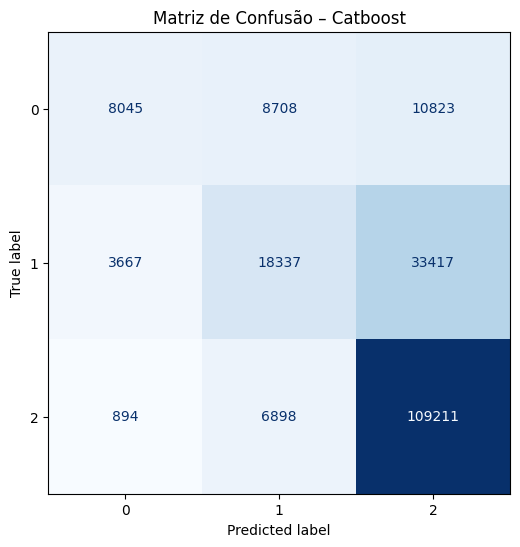

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de Confusão – Catboost")
plt.show()

### Análise da importância das variáveis

In [45]:
import pandas as pd
import numpy as np

preprocess = pipeline_final.named_steps["preprocess"]
model = pipeline_final.named_steps["model"]
cat = model.model if hasattr(model, "model") else model  # wrapper ou direto

X_test_tr = preprocess.transform(X_test)
feature_names = preprocess.get_feature_names_out()

imp = cat.get_feature_importance(type="FeatureImportance")

df_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": imp
}).sort_values("importance", ascending=False)

df_importances.head(20)




,feature,importance
5,pct__PCT_1_INFANCIA,11.499202
15,pct__PCT_7A18_ESCOLA_PUBLICA,10.424019
9,pct__PCT_ADULTOS_30A59,9.409716
136,multicat__CO_AFASTADO_TRAB_MEMB_-1,9.396907
154,geo__CO_MUNIC_IBGE_2_FAM,7.220006
4,quant__IDADE_REFERENCIA,6.846134
11,pct__PCT_IDOSOS_BPC,5.790153
0,quant__QT_PESSOAS_DOMIC_FAM,4.216724
140,multicat__CO_PRINCIPAL_TRAB_MEMB_1,4.128377
8,pct__PCT_JOVENS_19A29,2.524581


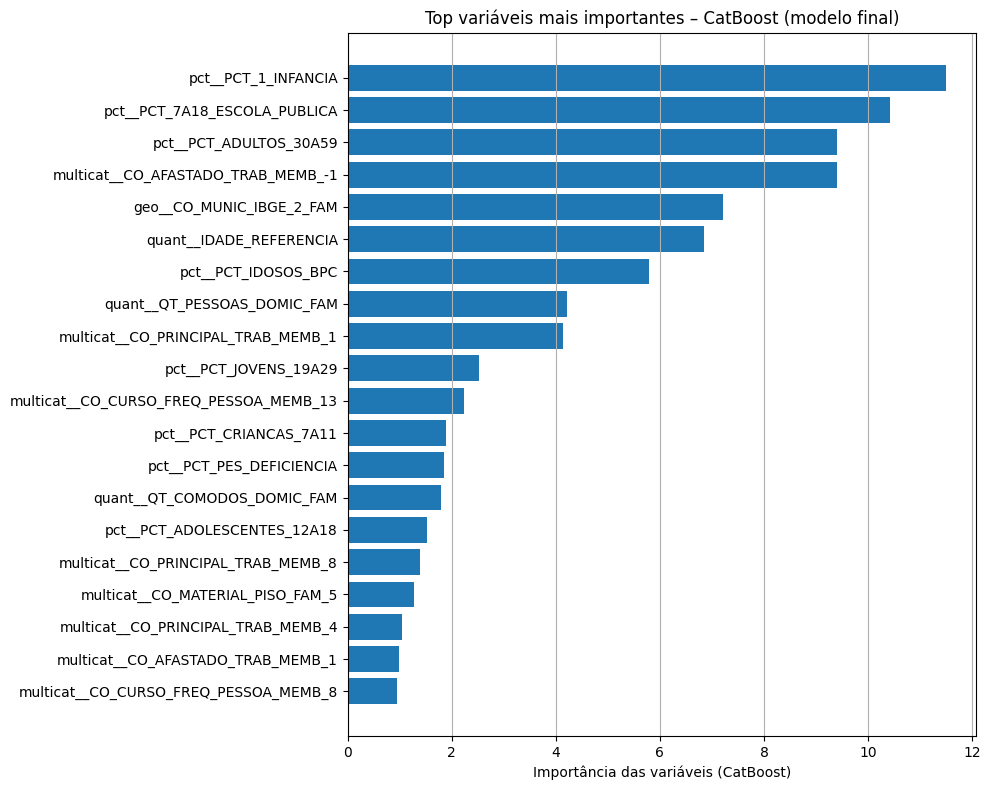

In [47]:
import matplotlib.pyplot as plt

top_n = 20
top_features = df_importances.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(
    top_features["feature"],
    top_features["importance"]
)
plt.gca().invert_yaxis()

plt.xlabel("Importância das variáveis (CatBoost)")
plt.title("Top variáveis mais importantes – CatBoost (modelo final)")
plt.grid(axis="x")

plt.tight_layout()
plt.show()


# Pipeline processamento + Modelo (XGBoost)

In [58]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
CLASSE_FOCO = 2
THRESHOLDS = np.arange(0.30, 0.61, 0.05)  # ajuste fino se quiser

# usar o melhor XGBoost já treinado
pipe = None
for nome, p in pipes.items():
    if nome == "XGBoost":
        pipe = p
        break

assert pipe is not None, "Pipeline XGBoost não encontrado em pipes"

# ------------------------------------------------------------
# PROBABILIDADES BASE
# ------------------------------------------------------------
proba = pipe.predict_proba(X_test)        # shape (n, 3)
pred_base = pipe.predict(X_test).ravel()  # argmax padrão

rows = []

for t in THRESHOLDS:
    y_pred_thr = pred_base.copy()

    # regra de override para classe 2
    mask = proba[:, CLASSE_FOCO] >= t
    y_pred_thr[mask] = CLASSE_FOCO

    # métricas focadas na classe 2
    prec = precision_score(
        y_test, y_pred_thr,
        labels=[CLASSE_FOCO],
        average="macro",
        zero_division=0
    )
    rec = recall_score(
        y_test, y_pred_thr,
        labels=[CLASSE_FOCO],
        average="macro",
        zero_division=0
    )
    f1 = f1_score(
        y_test, y_pred_thr,
        labels=[CLASSE_FOCO],
        average="macro",
        zero_division=0
    )

    # FN e FP explícitos (classe 2)
    cm = confusion_matrix(y_test, y_pred_thr, labels=[0, 1, 2])
    TP = cm[2, 2]
    FN = cm[2, 0] + cm[2, 1]
    FP = cm[0, 2] + cm[1, 2]

    rows.append({
        "threshold_cl2": float(t),
        "recall_cl2": float(rec),
        "precision_cl2": float(prec),
        "f1_cl2": float(f1),
        "FN_cl2": int(FN),
        "FP_cl2": int(FP),
    })

df_threshold_xgb = pd.DataFrame(rows)

# ordenar priorizando recall (FN ↓) e depois precisão (FP ↓)
df_threshold_xgb = df_threshold_xgb.sort_values(
    ["recall_cl2", "precision_cl2"],
    ascending=False
).reset_index(drop=True)

print("=== AJUSTE DE THRESHOLD – XGBoost (Classe 2) ===")
display(df_threshold_xgb)


=== AJUSTE DE THRESHOLD – XGBoost (Classe 2) ===


,threshold_cl2,recall_cl2,precision_cl2,f1_cl2,FN_cl2,FP_cl2
0,0.30,0.951933,0.696829,0.804645,5624,48458
1,0.35,0.933344,0.713719,0.808889,7799,43803
2,0.40,0.914173,0.727141,0.810001,10042,40137
3,0.45,0.900020,0.735324,0.809379,11698,37904
4,0.50,0.897849,0.736136,0.808990,11952,37655
5,0.55,0.897849,0.736136,0.808990,11952,37655
6,0.60,0.897849,0.736136,0.808990,11952,37655


In [56]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted
import numpy as np
from xgboost import XGBClassifier

class XGBoostComThreshold(BaseEstimator, ClassifierMixin):
    def __init__(self, threshold_cl2=0.45):
        self.threshold_cl2 = threshold_cl2

        self.model = XGBClassifier(
            n_estimators=300,
            learning_rate=0.1,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="multi:softprob",
            eval_metric="mlogloss",
            tree_method="hist",
            random_state=42,
            n_jobs=-1
        )

    def fit(self, X, y):
        self.model.fit(X, y)
        self.classes_ = np.unique(y)
        return self

    def predict_proba(self, X):
        check_is_fitted(self, attributes=["classes_"])
        return self.model.predict_proba(X)

    def predict(self, X):
        check_is_fitted(self, attributes=["classes_"])
        proba = self.model.predict_proba(X)
        y_pred = np.argmax(proba, axis=1)
        y_pred[proba[:, 2] >= self.threshold_cl2] = 2
        return y_pred


In [57]:
from sklearn.pipeline import Pipeline

pipeline_xgb_final = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBoostComThreshold(threshold_cl2=0.45))
])

pipeline_xgb_final.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('quant',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  ['QT_PESSOAS_DOMIC_FAM',
                                                   'QT_FAMILIAS_DOMIC_FAM',
                                                   'QT_COMODOS_DOMIC_FAM',
                                                   'QT_COMODOS_DORMITORIO_FAM',
                                                   'IDADE_REFERENCIA']),
                                                 ('pct', 'passthrough',
                                                  ['PCT_1_INFANCIA',
                                                   'PCT_CRIANCAS_7A11',
                                                   'PCT_ADOLESCE...
                                                   'IN_FAMILIA_QUILOMBOLA_FAM',
                                                   'IN_PARC_MDS_FAM',
                                                   'CO_RACA_COR_PESSOA',
                                                   'CO_DEFICIENCIA_MEMB',
                                                   'CO_SABE_LER_ESCREVER_MEMB',
                                                   'CO_CURSO_FREQUENTA_MEMB',
                                                   'CO_CURSO_FREQ_PESSOA_MEMB',
                                                   'CO_AFASTADO_TRAB_MEMB',
                                                   'CO_PRINCIPAL_TRAB_MEMB',
                                                   'CO_TRABALHO_12_MESES_MEMB']),
                                                 ('geo', 'passthrough',
                                                  ['CO_MUNIC_IBGE_2_FAM',
                                                   'CO_MUNIC_IBGE_5_FAM'])])),
                ('model', XGBoostComThreshold())])

## Avaliação completa do Modelo

### Predições do teste

In [61]:
y_pred_xgb = pipeline_xgb_final.predict(X_test)
y_proba_xgb = pipeline_xgb_final.predict_proba(X_test)  # para AUC

### Acurácia, F1, precisão e revocação

In [62]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

acc = accuracy_score(y_test, y_pred_xgb)

f1_macro = f1_score(y_test, y_pred_xgb, average="macro")
f1_weighted = f1_score(y_test, y_pred_xgb, average="weighted")

precision_macro = precision_score(y_test, y_pred_xgb, average="macro", zero_division=0)
recall_macro = recall_score(y_test, y_pred_xgb, average="macro", zero_division=0)

precision_weighted = precision_score(y_test, y_pred_xgb, average="weighted", zero_division=0)
recall_weighted = recall_score(y_test, y_pred_xgb, average="weighted", zero_division=0)

print(f"Acurácia: {acc:.3f}")
print(f"F1 macro: {f1_macro:.3f}")
print(f"F1 weighted: {f1_weighted:.3f}")
print(f"Precisão macro: {precision_macro:.3f}")
print(f"Revocação macro: {recall_macro:.3f}")
print(f"Precisão weighted: {precision_weighted:.3f}")
print(f"Revocação weighted: {recall_weighted:.3f}")

Acurácia: 0.683
F1 macro: 0.562
F1 weighted: 0.659
Precisão macro: 0.632
Revocação macro: 0.540
Precisão weighted: 0.663
Revocação weighted: 0.683


### Classification report

In [63]:
print("Classification report:")
print(classification_report(y_test, y_pred_xgb))

Classification report:
              precision    recall  f1-score   support

           0       0.63      0.31      0.42     27576
           1       0.53      0.41      0.46     55421
           2       0.74      0.90      0.81    117003

    accuracy                           0.68    200000
   macro avg       0.63      0.54      0.56    200000
weighted avg       0.66      0.68      0.66    200000



### Matriz de confusão

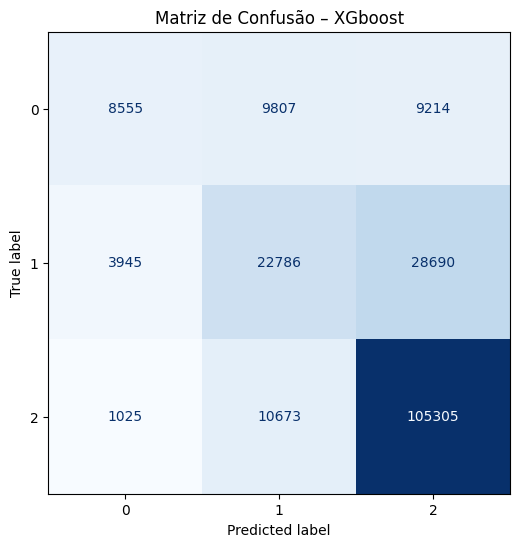

In [65]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de Confusão – XGboost")
plt.show()

## Análise da importância das variáveis

In [68]:
import pandas as pd
import numpy as np

# 1) separar preprocess e modelo do pipeline
preprocess = pipeline_xgb_final.named_steps["preprocess"]
model_step = pipeline_xgb_final.named_steps["model"]
xgb = model_step.model if hasattr(model_step, "model") else model_step

# 2) nomes das features após preprocess (one-hot incluído)
feature_names = preprocess.get_feature_names_out()

# 3) importância pelo GAIN
booster = xgb.get_booster()
score_gain = booster.get_score(importance_type="gain")  # dict: {"f0":..., "f1":...}

imp = np.zeros(len(feature_names), dtype=float)
for k, v in score_gain.items():
    idx = int(k[1:])  # "f123" -> 123
    if idx < len(imp):
        imp[idx] = v

df_importances = pd.DataFrame({
    "feature": feature_names,
    "importance_gain": imp
}).sort_values("importance_gain", ascending=False)

df_importances.head(20)


,feature,importance_gain
5,pct__PCT_1_INFANCIA,146.490723
15,pct__PCT_7A18_ESCOLA_PUBLICA,145.372147
11,pct__PCT_IDOSOS_BPC,142.323685
139,multicat__CO_PRINCIPAL_TRAB_MEMB_-1,118.441788
136,multicat__CO_AFASTADO_TRAB_MEMB_-1,90.180321
140,multicat__CO_PRINCIPAL_TRAB_MEMB_1,84.502243
133,multicat__CO_CURSO_FREQ_PESSOA_MEMB_13,79.183228
9,pct__PCT_ADULTOS_30A59,69.125885
44,multicat__CO_MATERIAL_PISO_FAM_5,67.075737
138,multicat__CO_AFASTADO_TRAB_MEMB_2,51.438499


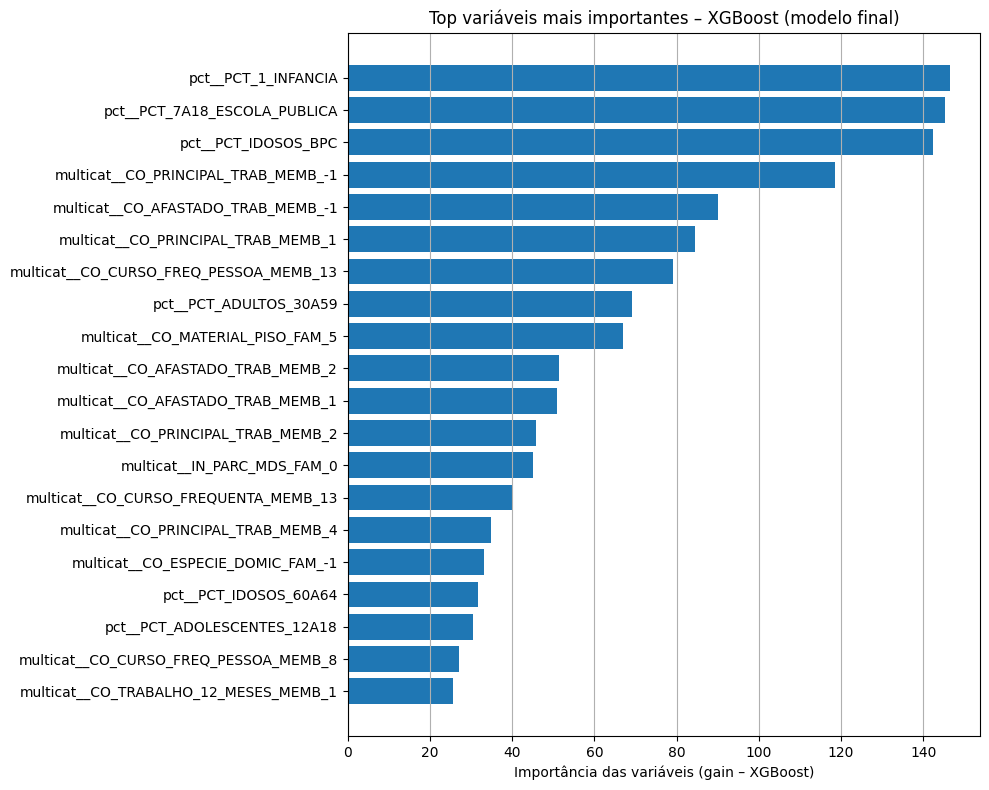

In [69]:
import matplotlib.pyplot as plt

top_n = 20
top_features = df_importances.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(
    top_features["feature"],
    top_features["importance_gain"]
)
plt.gca().invert_yaxis()

plt.xlabel("Importância das variáveis (gain – XGBoost)")
plt.title("Top variáveis mais importantes – XGBoost (modelo final)")
plt.grid(axis="x")

plt.tight_layout()
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_20380\2791052593.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = (df_plot.groupby(["bin", target]).size().unstack(fill_value=0).reindex(columns=CLASSES, fill_value=0))


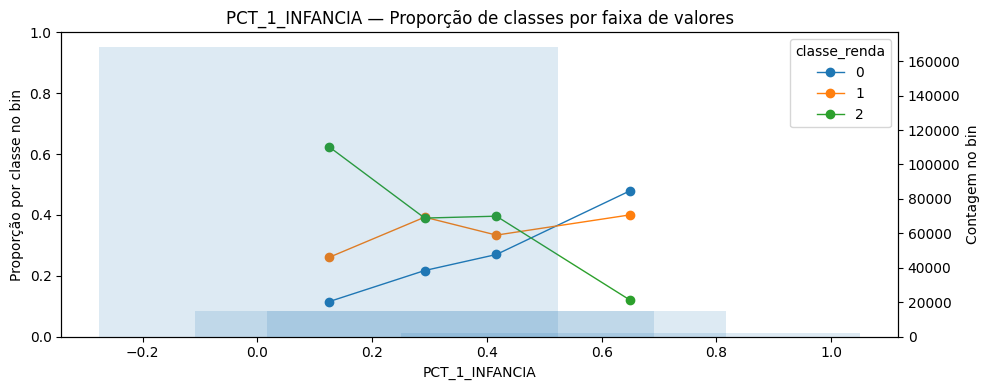

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

col = "PCT_1_INFANCIA"
target = "classe_renda"
CLASSES = [0, 1, 2]
N_BINS = 20

df_plot = X_test[[col]].copy()
df_plot[target] = y_test

df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")
df_plot = df_plot.dropna()

df_plot["bin"] = pd.qcut(df_plot[col], q=min(N_BINS, df_plot[col].nunique()), duplicates="drop")

tab = (df_plot.groupby(["bin", target]).size().unstack(fill_value=0).reindex(columns=CLASSES, fill_value=0))
prop = tab.div(tab.sum(axis=1), axis=0)

centers = np.array([(b.left + b.right) / 2 for b in prop.index])
counts = tab.sum(axis=1).to_numpy()

fig, ax1 = plt.subplots(figsize=(10, 4))
for k in CLASSES:
    ax1.plot(centers, prop[k].to_numpy(), marker="o", linewidth=1, label=str(k))

ax1.set_ylim(0, 1)
ax1.set_xlabel(col)
ax1.set_ylabel("Proporção por classe no bin")
ax1.set_title(f"{col} — Proporção de classes por faixa de valores")
ax1.legend(title="classe_renda", loc="upper right")
ax1.grid(False)

ax2 = ax1.twinx()
ax2.bar(centers, counts, alpha=0.15)
ax2.set_ylabel("Contagem no bin")

plt.tight_layout()
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_20380\242388325.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = (df_plot.groupby(["bin", target]).size().unstack(fill_value=0).reindex(columns=CLASSES, fill_value=0))


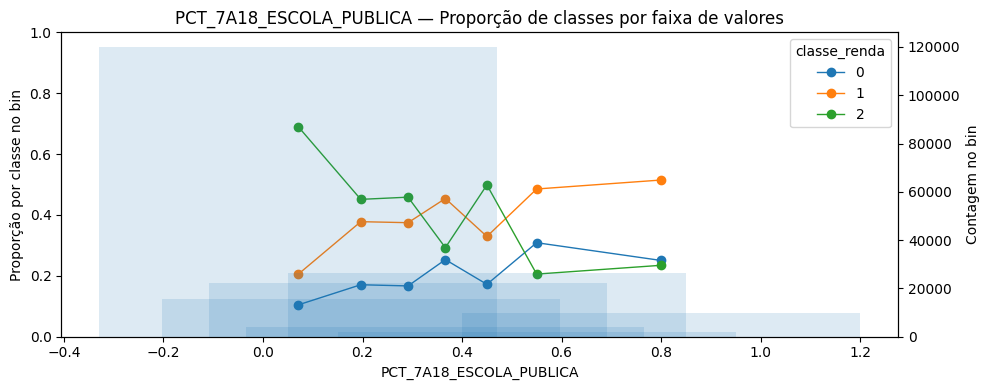

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

col = "PCT_7A18_ESCOLA_PUBLICA"
target = "classe_renda"
CLASSES = [0, 1, 2]
N_BINS = 20

df_plot = X_test[[col]].copy()
df_plot[target] = y_test

df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")
df_plot = df_plot.dropna()

df_plot["bin"] = pd.qcut(df_plot[col], q=min(N_BINS, df_plot[col].nunique()), duplicates="drop")

tab = (df_plot.groupby(["bin", target]).size().unstack(fill_value=0).reindex(columns=CLASSES, fill_value=0))
prop = tab.div(tab.sum(axis=1), axis=0)

centers = np.array([(b.left + b.right) / 2 for b in prop.index])
counts = tab.sum(axis=1).to_numpy()

fig, ax1 = plt.subplots(figsize=(10, 4))
for k in CLASSES:
    ax1.plot(centers, prop[k].to_numpy(), marker="o", linewidth=1, label=str(k))

ax1.set_ylim(0, 1)
ax1.set_xlabel(col)
ax1.set_ylabel("Proporção por classe no bin")
ax1.set_title(f"{col} — Proporção de classes por faixa de valores")
ax1.legend(title="classe_renda", loc="upper right")
ax1.grid(False)

ax2 = ax1.twinx()
ax2.bar(centers, counts, alpha=0.15)
ax2.set_ylabel("Contagem no bin")

plt.tight_layout()
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_20380\754485389.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = (df_plot.groupby(["bin", target]).size().unstack(fill_value=0).reindex(columns=CLASSES, fill_value=0))


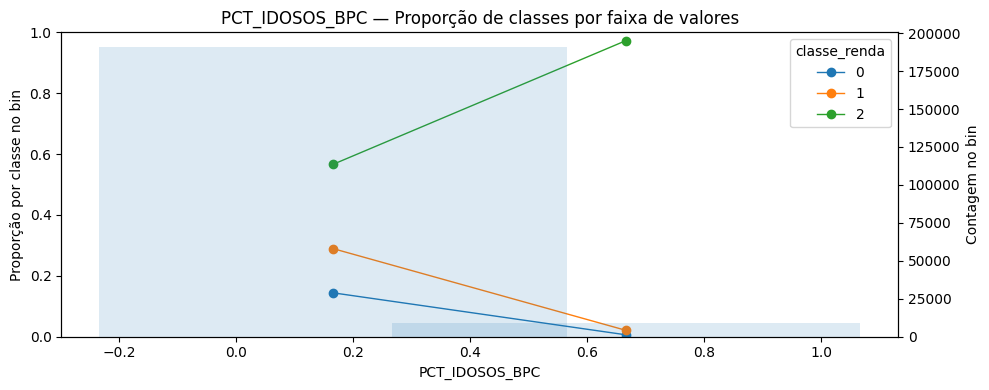

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

col = "PCT_IDOSOS_BPC"
target = "classe_renda"
CLASSES = [0, 1, 2]
N_BINS = 20

df_plot = X_test[[col]].copy()
df_plot[target] = y_test

df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")
df_plot = df_plot.dropna()

df_plot["bin"] = pd.qcut(df_plot[col], q=min(N_BINS, df_plot[col].nunique()), duplicates="drop")

tab = (df_plot.groupby(["bin", target]).size().unstack(fill_value=0).reindex(columns=CLASSES, fill_value=0))
prop = tab.div(tab.sum(axis=1), axis=0)

centers = np.array([(b.left + b.right) / 2 for b in prop.index])
counts = tab.sum(axis=1).to_numpy()

fig, ax1 = plt.subplots(figsize=(10, 4))
for k in CLASSES:
    ax1.plot(centers, prop[k].to_numpy(), marker="o", linewidth=1, label=str(k))

ax1.set_ylim(0, 1)
ax1.set_xlabel(col)
ax1.set_ylabel("Proporção por classe no bin")
ax1.set_title(f"{col} — Proporção de classes por faixa de valores")
ax1.legend(title="classe_renda", loc="upper right")
ax1.grid(False)

ax2 = ax1.twinx()
ax2.bar(centers, counts, alpha=0.15)
ax2.set_ylabel("Contagem no bin")

plt.tight_layout()
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_20380\1102678014.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = (df_plot.groupby(["bin", target]).size().unstack(fill_value=0).reindex(columns=CLASSES, fill_value=0))


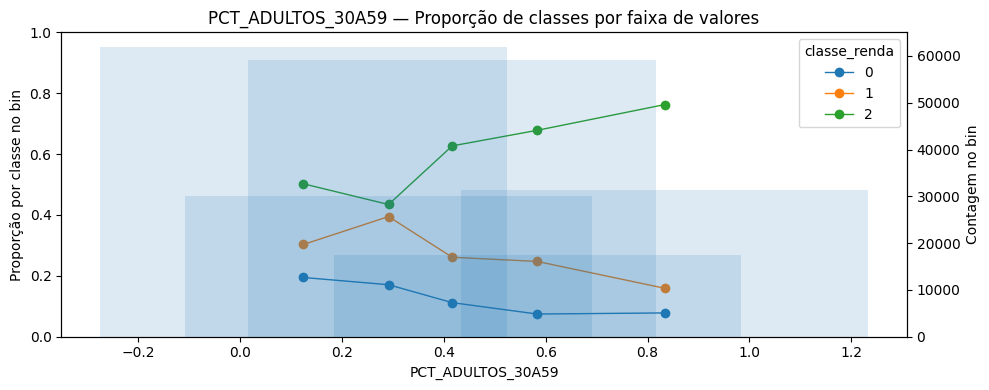

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

col = "PCT_ADULTOS_30A59"
target = "classe_renda"
CLASSES = [0, 1, 2]
N_BINS = 20

df_plot = X_test[[col]].copy()
df_plot[target] = y_test

df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")
df_plot = df_plot.dropna()

df_plot["bin"] = pd.qcut(df_plot[col], q=min(N_BINS, df_plot[col].nunique()), duplicates="drop")

tab = (df_plot.groupby(["bin", target]).size().unstack(fill_value=0).reindex(columns=CLASSES, fill_value=0))
prop = tab.div(tab.sum(axis=1), axis=0)

centers = np.array([(b.left + b.right) / 2 for b in prop.index])
counts = tab.sum(axis=1).to_numpy()

fig, ax1 = plt.subplots(figsize=(10, 4))
for k in CLASSES:
    ax1.plot(centers, prop[k].to_numpy(), marker="o", linewidth=1, label=str(k))

ax1.set_ylim(0, 1)
ax1.set_xlabel(col)
ax1.set_ylabel("Proporção por classe no bin")
ax1.set_title(f"{col} — Proporção de classes por faixa de valores")
ax1.legend(title="classe_renda", loc="upper right")
ax1.grid(False)

ax2 = ax1.twinx()
ax2.bar(centers, counts, alpha=0.15)
ax2.set_ylabel("Contagem no bin")

plt.tight_layout()
plt.show()


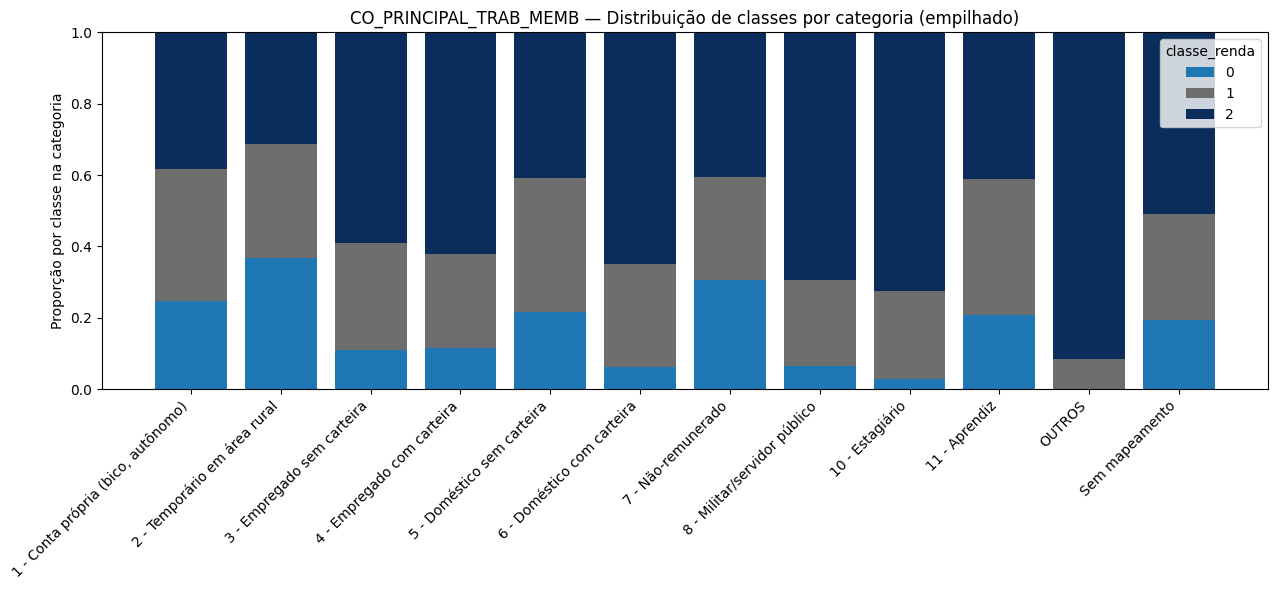

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

col = "CO_PRINCIPAL_TRAB_MEMB"
target = "classe_renda"
CLASSES = [0, 1, 2]
TOP_CAT = 20
MIN_COUNT = 50

# -----------------------------
# MAPEAMENTO (conforme anexo)
# -----------------------------
map_trab = {
    1: "1 - Conta própria (bico, autônomo)",
    2: "2 - Temporário em área rural",
    3: "3 - Empregado sem carteira",
    4: "4 - Empregado com carteira",
    5: "5 - Doméstico sem carteira",
    6: "6 - Doméstico com carteira",
    7: "7 - Não-remunerado",
    8: "8 - Militar/servidor público",
    9: "9 - Empregador",
    10: "10 - Estagiário",
    11: "11 - Aprendiz",
}

# -----------------------------
# DADOS
# -----------------------------
df_plot = X_test[[col]].copy()
df_plot[target] = y_test

# garantir numérico (se vier como object)
df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")

# agrupar categorias raras em OUTROS (com base no código)
vc = df_plot[col].value_counts(dropna=False)
raras = vc[vc < MIN_COUNT].index
df_plot[col] = df_plot[col].where(~df_plot[col].isin(raras), other="OUTROS")

# criar coluna de rótulo com mapeamento
df_plot["rotulo"] = df_plot[col].map(map_trab)
df_plot.loc[df_plot[col].eq("OUTROS"), "rotulo"] = "OUTROS"
df_plot.loc[df_plot["rotulo"].isna(), "rotulo"] = "Sem mapeamento"

# pega top categorias por frequência (usando rótulo)
top = df_plot["rotulo"].value_counts().head(TOP_CAT).index
df_plot = df_plot[df_plot["rotulo"].isin(top)]

# tabela: proporção por classe dentro de cada categoria
tab = (
    df_plot.groupby(["rotulo", target]).size()
    .unstack(fill_value=0)
    .reindex(columns=CLASSES, fill_value=0)
)
prop = tab.div(tab.sum(axis=1), axis=0)

# ordenar rótulos pelo código (quando possível)
def ordem_rotulo(r):
    if r == "OUTROS": 
        return 9998
    if r == "Sem mapeamento":
        return 9999
    try:
        return int(str(r).split(" - ", 1)[0])
    except Exception:
        return 9997

prop = prop.loc[sorted(prop.index, key=ordem_rotulo)]

# -----------------------------
# PLOT (cores fechadas)
# -----------------------------
cores = {
    0: "#1f77b4",  # azul médio (fechado)
    1: "#6e6e6e",  # cinza médio (fechado)
    2: "#0b2d5b",  # azul escuro (fechado)
}

x = np.arange(len(prop.index))
bottom = np.zeros(len(prop.index))

plt.figure(figsize=(13, 6))
for k in CLASSES:
    vals = prop[k].to_numpy()
    plt.bar(x, vals, bottom=bottom, label=str(k), color=cores[k])
    bottom += vals

plt.xticks(x, prop.index, rotation=45, ha="right")
plt.ylim(0, 1)
plt.ylabel("Proporção por classe na categoria")
plt.title(f"{col} — Distribuição de classes por categoria (empilhado)")
plt.legend(title="classe_renda", loc="upper right")
plt.tight_layout()
plt.show()



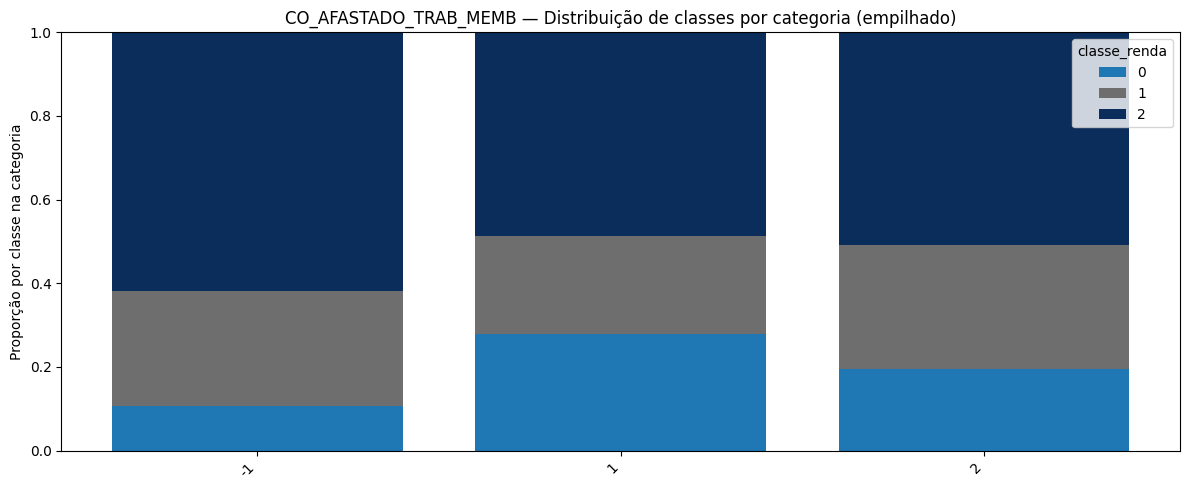

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

col = "CO_AFASTADO_TRAB_MEMB"
target = "classe_renda"
CLASSES = [0, 1, 2]
TOP_CAT = 20
MIN_COUNT = 50

df_plot = X_test[[col]].copy()
df_plot[target] = y_test

vc = df_plot[col].value_counts(dropna=False)
raras = vc[vc < MIN_COUNT].index
df_plot[col] = df_plot[col].where(~df_plot[col].isin(raras), other="OUTROS")

top = df_plot[col].value_counts().head(TOP_CAT).index
df_plot = df_plot[df_plot[col].isin(top)]

tab = (df_plot.groupby([col, target]).size().unstack(fill_value=0).reindex(columns=CLASSES, fill_value=0))
prop = tab.div(tab.sum(axis=1), axis=0)

cores = {
    0: "#1f77b4",  # azul médio (fechado)
    1: "#6e6e6e",  # cinza médio (fechado)
    2: "#0b2d5b",  # azul escuro (fechado)
}

x = np.arange(len(prop.index))
bottom = np.zeros(len(prop.index))

plt.figure(figsize=(12, 5))
for k in CLASSES:
    vals = prop[k].to_numpy()
    plt.bar(
    x,
    vals,
    bottom=bottom,
    label=str(k),
    color=cores[k]   # ← AQUI está o ajuste
)
    bottom += vals

plt.xticks(x, [str(v) for v in prop.index], rotation=45, ha="right")
plt.ylim(0, 1)
plt.ylabel("Proporção por classe na categoria")
plt.title(f"{col} — Distribuição de classes por categoria (empilhado)")
plt.legend(title="classe_renda", loc="upper right")
plt.tight_layout()
plt.show()


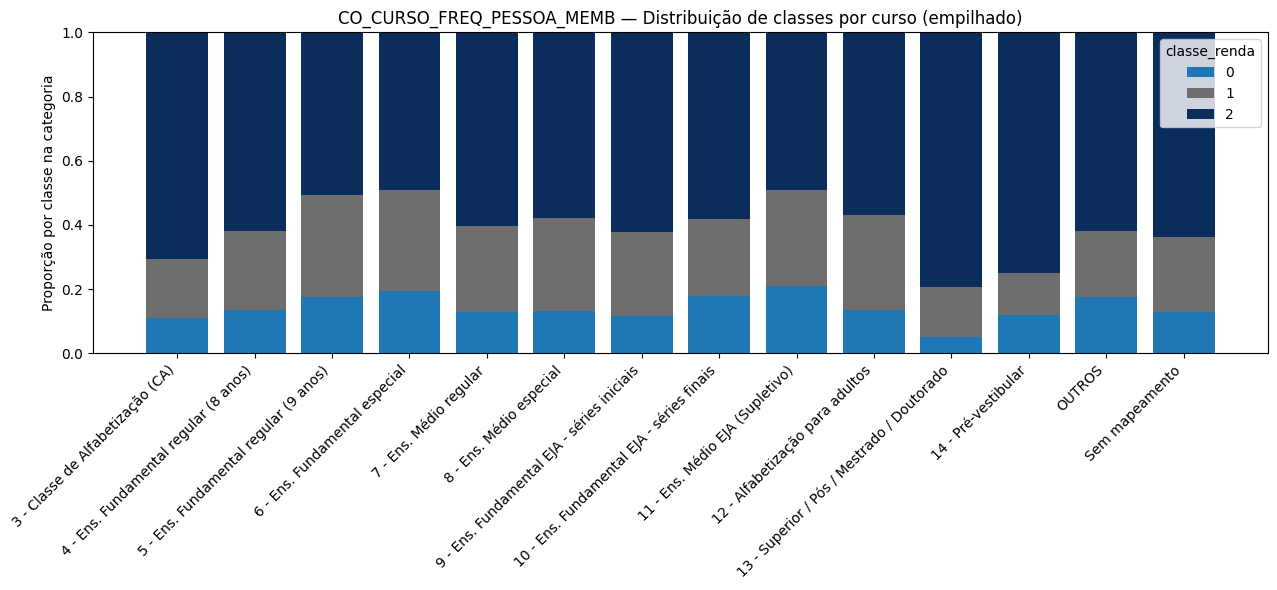

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

col = "CO_CURSO_FREQ_PESSOA_MEMB"
target = "classe_renda"
CLASSES = [0, 1, 2]
TOP_CAT = 20
MIN_COUNT = 50

# -----------------------------
# CORES PADRÃO (fechadas)
# -----------------------------
cores = {
    0: "#1f77b4",  # azul médio (fechado)
    1: "#6e6e6e",  # cinza médio (fechado)
    2: "#0b2d5b",  # azul escuro (fechado)
}

# -----------------------------
# MAPEAMENTO (conforme anexo)
# -----------------------------
map_curso = {
    1:  "1 - Creche",
    2:  "2 - Pré-escola (exceto CA)",
    3:  "3 - Classe de Alfabetização (CA)",
    4:  "4 - Ens. Fundamental regular (8 anos)",
    5:  "5 - Ens. Fundamental regular (9 anos)",
    6:  "6 - Ens. Fundamental especial",
    7:  "7 - Ens. Médio regular",
    8:  "8 - Ens. Médio especial",
    9:  "9 - Ens. Fundamental EJA - séries iniciais",
    10: "10 - Ens. Fundamental EJA - séries finais",
    11: "11 - Ens. Médio EJA (Supletivo)",
    12: "12 - Alfabetização para adultos",
    13: "13 - Superior / Pós / Mestrado / Doutorado",
    14: "14 - Pré-vestibular",
}

# -----------------------------
# DADOS
# -----------------------------
df_plot = X_test[[col]].copy()
df_plot[target] = y_test

# garantir numérico (se vier como object)
df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")

# agrupar categorias raras (com base no código)
vc = df_plot[col].value_counts(dropna=False)
raras = vc[vc < MIN_COUNT].index
df_plot[col] = df_plot[col].where(~df_plot[col].isin(raras), other="OUTROS")

# criar rótulos
df_plot["rotulo"] = df_plot[col].map(map_curso)
df_plot.loc[df_plot[col].eq("OUTROS"), "rotulo"] = "OUTROS"
df_plot.loc[df_plot["rotulo"].isna(), "rotulo"] = "Sem mapeamento"

# top categorias por frequência (usando rótulo)
top = df_plot["rotulo"].value_counts().head(TOP_CAT).index
df_plot = df_plot[df_plot["rotulo"].isin(top)]

# proporções por classe dentro de cada categoria
tab = (
    df_plot.groupby(["rotulo", target]).size()
    .unstack(fill_value=0)
    .reindex(columns=CLASSES, fill_value=0)
)
prop = tab.div(tab.sum(axis=1), axis=0)

# ordenar rótulos pelo código (quando possível)
def ordem_rotulo(r):
    if r == "OUTROS":
        return 9998
    if r == "Sem mapeamento":
        return 9999
    try:
        return int(str(r).split(" - ", 1)[0])
    except Exception:
        return 9997

prop = prop.loc[sorted(prop.index, key=ordem_rotulo)]

# -----------------------------
# PLOT (empilhado)
# -----------------------------
x = np.arange(len(prop.index))
bottom = np.zeros(len(prop.index))

plt.figure(figsize=(13, 6))
for k in CLASSES:
    vals = prop[k].to_numpy()
    plt.bar(x, vals, bottom=bottom, label=str(k), color=cores[k])
    bottom += vals

plt.xticks(x, prop.index, rotation=45, ha="right")
plt.ylim(0, 1)
plt.ylabel("Proporção por classe na categoria")
plt.title(f"{col} — Distribuição de classes por curso (empilhado)")
plt.legend(title="classe_renda", loc="upper right")
plt.tight_layout()
plt.show()

